In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("substancias_remineralizadoras.csv")

df.head()

,Autor,Ano,Substancia 1,Substancia 2,Substancia 3,Substância 4,Substancia 5,Concentração substancia 1,Concentração substancia 2,Concentração substancia 3,...,Area_de_superficie_polar,Teste_microdureza,Tempo Teste EDX (dias),Teste_EDX,Tempo microscopia (dias),Microscopia_eletrônica (micrometros) µm²,Microscopia_eletrônica (classificação),Mineraliza ou não,Doi,Justificativa
0,"Goldberg, Michel et al.",2011,colageno_tipo_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,https://pmc.ncbi.nlm.nih.gov/articles/PMC3360947/,NaN
1,"Goldberg, Michel et al.",2011,colageno_tipo_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
2,"Goldberg, Michel et al.",2011,hidroxiapatita,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,556.5,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
3,"Goldberg, Michel et al.",2011,glicoproteina_Da_dentina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
4,"Goldberg, Michel et al.",2011,sialoproteina_ossea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


In [3]:
df.shape

(109, 57)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 57 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Autor                                     109 non-null    str    
 1   Ano                                       109 non-null    int64  
 2   Substancia 1                              109 non-null    str    
 3   Substancia 2                              35 non-null     str    
 4   Substancia 3                              8 non-null      str    
 5   Substância 4                              5 non-null      str    
 6   Substancia 5                              1 non-null      str    
 7   Concentração substancia 1                 24 non-null     str    
 8   Concentração substancia 2                 15 non-null     str    
 9   Concentração substancia 3                 8 non-null      str    
 10  Concentração substancia 4                 5 non-n

In [5]:
df.columns

Index(['Autor', 'Ano', 'Substancia 1', 'Substancia 2', 'Substancia 3',
       'Substância 4', 'Substancia 5', 'Concentração substancia 1',
       'Concentração substancia 2', 'Concentração substancia 3',
       'Concentração substancia 4', 'Concentração substancia 5',
       'Concentração g substancia 1', 'Porcentagem substancia 1',
       'Porcentagem substancia 2', 'Frequencia de aplicação/dia',
       'Tempo de aplicação (min)', 'Concentração Composição 1', 'Composição 1',
       'Concentração Composição 2', 'Composição 2',
       'Concentração Composição 3', 'Composição 3', 'Concentração comp 4',
       'Composição 4', 'Concentração comp 5', 'Composição 5',
       'Concentração comp 6', 'Composição 6', 'Composição 7', 'Composição 8',
       'Composição 9', 'Composição 10', 'Composição 11', 'Composição 12',
       'Composição 13', 'Composição 14', 'Composição 15', 'Composição 16',
       'Sequência de aminoácidos', 'Sequencia de aminoacidos 2',
       'Numero de aminoacidos', 'Formu

In [6]:
#conferir distribuição da variável alvo
df["Mineraliza ou não"].value_counts()

Mineraliza ou não
1    72
0    37
Name: count, dtype: int64

In [7]:
df["Mineraliza ou não"].value_counts(normalize=True) * 100

Mineraliza ou não
1    66.055046
0    33.944954
Name: proportion, dtype: float64

In [8]:
# Quantidade de valores ausentes por coluna
valores_ausentes = df.isnull().sum().sort_values(ascending=False)

valores_ausentes

Justificativa                               109
Concentração substancia 5                   108
Sequencia de aminoacidos 2                  108
Composição 12                               108
Composição 13                               108
Composição 14                               108
Composição 16                               108
Composição 15                               108
Substancia 5                                108
Concentração comp 6                         107
Porcentagem substancia 2                    105
Composição 9                                105
Microscopia_eletrônica (micrometros) µm²    105
Concentração comp 5                         105
Composição 11                               105
Composição 10                               105
Substância 4                                104
Concentração substancia 4                   104
Frequencia de aplicação/dia                 104
pH                                          103
Area_de_superficie_polar                

In [9]:
# Tabela com quantidade e percentual de valores ausentes
missing = pd.DataFrame({
    "valores_ausentes": df.isnull().sum(),
    "percentual_ausente": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(by="percentual_ausente", ascending=False)

missing

,valores_ausentes,percentual_ausente
Justificativa,109,100.000000
Concentração substancia 5,108,99.082569
Sequencia de aminoacidos 2,108,99.082569
Composição 12,108,99.082569
Composição 13,108,99.082569
Composição 14,108,99.082569
Composição 16,108,99.082569
Composição 15,108,99.082569
Substancia 5,108,99.082569
Concentração comp 6,107,98.165138


## Análise inicial da variável alvo

A variável alvo utilizada foi "Mineraliza ou não", na qual:

- 1 representa substâncias com potencial/evidência de mineralização ou remineralização.
- 0 representa substâncias sem potencial/evidência suficiente.

A base possui 109 registros, sendo 72 classificados como positivos e 37 como negativos. Portanto, há um desbalanceamento moderado entre as classes, com predominância da classe positiva.

## Análise de valores ausentes

A análise de valores ausentes mostrou que muitas variáveis apresentam alto percentual de dados faltantes. Isso indica que a base é esparsa, possivelmente devido à heterogeneidade dos artigos utilizados na construção do dataset.

A variável alvo "Mineraliza ou não" está completa, com 109 registros preenchidos. No entanto, várias variáveis físico-químicas e experimentais possuem mais de 70% de valores ausentes, o que limita sua utilização direta no modelo.

Por esse motivo, a seleção de variáveis para o primeiro modelo será feita de forma conservadora, priorizando colunas com maior preenchimento e evitando variáveis que possam causar vazamento de dados.

In [10]:
alvo = "Mineraliza ou não"

colunas_identificacao = [
    "Autor",
    "Ano",
    "Doi",
    "Justificativa"
]

colunas_experimentais = [
    "Teste_microdureza",
    "Tempo Teste EDX (dias)",
    "Teste_EDX",
    "Tempo microscopia (dias)",
    "Microscopia_eletrônica (micrometros) µm²",
    "Microscopia_eletrônica (classificação)"
]

In [11]:
colunas_candidatas = [
    col for col in df.columns
    if col not in colunas_identificacao
    and col not in colunas_experimentais
    and col != alvo
]

colunas_candidatas

['Substancia 1',
 'Substancia 2',
 'Substancia 3',
 'Substância 4',
 'Substancia 5',
 'Concentração substancia 1',
 'Concentração substancia 2',
 'Concentração substancia 3',
 'Concentração substancia 4',
 'Concentração substancia 5',
 'Concentração g substancia 1',
 'Porcentagem substancia 1',
 'Porcentagem substancia 2',
 'Frequencia de aplicação/dia',
 'Tempo de aplicação (min)',
 'Concentração Composição 1',
 'Composição 1',
 'Concentração Composição 2',
 'Composição 2',
 'Concentração Composição 3',
 'Composição 3',
 'Concentração comp 4',
 'Composição 4',
 'Concentração comp 5',
 'Composição 5',
 'Concentração comp 6',
 'Composição 6',
 'Composição 7',
 'Composição 8',
 'Composição 9',
 'Composição 10',
 'Composição 11',
 'Composição 12',
 'Composição 13',
 'Composição 14',
 'Composição 15',
 'Composição 16',
 'Sequência de aminoácidos',
 'Sequencia de aminoacidos 2',
 'Numero de aminoacidos',
 'Formula_molecular',
 'pH',
 'Peso_molecular (g/mol)',
 'Aceptores_de_ligacoes_de_hidr

In [12]:
missing_candidatas = missing.loc[colunas_candidatas].sort_values(
    by="percentual_ausente",
    ascending=False
)

missing_candidatas

,valores_ausentes,percentual_ausente
Substancia 5,108,99.082569
Concentração substancia 5,108,99.082569
Composição 16,108,99.082569
Sequencia de aminoacidos 2,108,99.082569
Composição 15,108,99.082569
Composição 14,108,99.082569
Composição 13,108,99.082569
Composição 12,108,99.082569
Concentração comp 6,107,98.165138
Concentração comp 5,105,96.330275


In [13]:
colunas_com_menos_ausentes = missing_candidatas[
    missing_candidatas["percentual_ausente"] <= 85
].index.tolist()

colunas_com_menos_ausentes

['Sequência de aminoácidos',
 'Concentração Composição 1',
 'Composição 5',
 'Concentração substancia 1',
 'Composição 4',
 'Substancia 2',
 'Composição 3',
 'Composição 2',
 'Composição 1',
 'Substancia 1']

In [14]:
df_modelo = df[colunas_com_menos_ausentes + [alvo]].copy()

df_modelo.head()

,Sequência de aminoácidos,Concentração Composição 1,Composição 5,Concentração substancia 1,Composição 4,Substancia 2,Composição 3,Composição 2,Composição 1,Substancia 1,Mineraliza ou não
0,MFSFVDLRLLLLLGATALLTHGQEDIPEVSCIHNGLRVPNGETWKP...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colageno_tipo_1,0
1,MMSFVQKGSWLLLALLHPTIILAQQEAVEGGCSHLGQSYADRDVWK...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colageno_tipo_3,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hidroxiapatita,0
3,IPVPKGNFPKGMAREANTGGDDPKTTMSPSTSSVSSGNGSVTNSGI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,glicoproteina_Da_dentina,0
4,MKTALILLSILGMACAFSMKNLHRRVKIEDSEENGVFKYRPRYYLY...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sialoproteina_ossea,0


In [15]:
df_modelo.shape

(109, 11)

In [16]:
colunas_com_menos_ausentes

['Sequência de aminoácidos',
 'Concentração Composição 1',
 'Composição 5',
 'Concentração substancia 1',
 'Composição 4',
 'Substancia 2',
 'Composição 3',
 'Composição 2',
 'Composição 1',
 'Substancia 1']

In [17]:
alvo = "Mineraliza ou não"

features_modelo_1 = [
    'Sequência de aminoácidos',
    'Concentração Composição 1',
    'Composição 5',
    'Concentração substancia 1',
    'Composição 4',
    'Substancia 2',
    'Composição 3',
    'Composição 2',
    'Composição 1',
    'Substancia 1'
]

df_modelo = df[features_modelo_1 + [alvo]].copy()

df_modelo.head()

,Sequência de aminoácidos,Concentração Composição 1,Composição 5,Concentração substancia 1,Composição 4,Substancia 2,Composição 3,Composição 2,Composição 1,Substancia 1,Mineraliza ou não
0,MFSFVDLRLLLLLGATALLTHGQEDIPEVSCIHNGLRVPNGETWKP...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colageno_tipo_1,0
1,MMSFVQKGSWLLLALLHPTIILAQQEAVEGGCSHLGQSYADRDVWK...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colageno_tipo_3,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hidroxiapatita,0
3,IPVPKGNFPKGMAREANTGGDDPKTTMSPSTSSVSSGNGSVTNSGI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,glicoproteina_Da_dentina,0
4,MKTALILLSILGMACAFSMKNLHRRVKIEDSEENGVFKYRPRYYLY...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sialoproteina_ossea,0


In [18]:
df_modelo.shape

(109, 11)

In [19]:
df_modelo.isnull().sum().sort_values(ascending=False)

Sequência de aminoácidos     92
Concentração Composição 1    90
Composição 5                 88
Concentração substancia 1    85
Composição 4                 82
Substancia 2                 74
Composição 3                 74
Composição 2                 61
Composição 1                 60
Substancia 1                  0
Mineraliza ou não             0
dtype: int64

In [20]:
df_modelo[features_modelo_1] = df_modelo[features_modelo_1].fillna("Não informado")

In [21]:
df_modelo.isnull().sum()

Sequência de aminoácidos     0
Concentração Composição 1    0
Composição 5                 0
Concentração substancia 1    0
Composição 4                 0
Substancia 2                 0
Composição 3                 0
Composição 2                 0
Composição 1                 0
Substancia 1                 0
Mineraliza ou não            0
dtype: int64

In [22]:
df_modelo[alvo].value_counts()

Mineraliza ou não
1    72
0    37
Name: count, dtype: int64

In [23]:
df_modelo.head()

,Sequência de aminoácidos,Concentração Composição 1,Composição 5,Concentração substancia 1,Composição 4,Substancia 2,Composição 3,Composição 2,Composição 1,Substancia 1,Mineraliza ou não
0,MFSFVDLRLLLLLGATALLTHGQEDIPEVSCIHNGLRVPNGETWKP...,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,colageno_tipo_1,0
1,MMSFVQKGSWLLLALLHPTIILAQQEAVEGGCSHLGQSYADRDVWK...,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,colageno_tipo_3,0
2,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,hidroxiapatita,0
3,IPVPKGNFPKGMAREANTGGDDPKTTMSPSTSSVSSGNGSVTNSGI...,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,glicoproteina_Da_dentina,0
4,MKTALILLSILGMACAFSMKNLHRRVKIEDSEENGVFKYRPRYYLY...,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,Não informado,sialoproteina_ossea,0


## Seleção inicial de variáveis

Para o primeiro modelo exploratório, foram selecionadas as colunas com percentual de valores ausentes menor ou igual a 85%, excluindo variáveis de identificação, referência bibliográfica e variáveis experimentais que poderiam causar vazamento de dados.

Como a maioria das variáveis selecionadas é categórica ou textual, os valores ausentes foram preenchidos com a categoria "Não informado". Essa estratégia foi adotada para evitar a exclusão de amostras, considerando o tamanho reduzido da base.

In [24]:
X = df_modelo[features_modelo_1]
y = df_modelo[alvo]

print(X.shape)
print(y.shape)

(109, 10)
(109,)


In [25]:
y.value_counts()

Mineraliza ou não
1    72
0    37
Name: count, dtype: int64

In [26]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [27]:
preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_modelo_1)
    ]
)

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [29]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [30]:
from sklearn.dummy import DummyClassifier

In [31]:
dummy_model = DummyClassifier(strategy="most_frequent")

resultados_dummy = cross_validate(
    dummy_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

resultados_dummy

{'fit_time': array([0.00209618, 0.0009172 , 0.00100303, 0.00100279, 0.00120568]),
 'score_time': array([0.00600529, 0.00603151, 0.00551367, 0.0053823 , 0.00268173]),
 'test_accuracy': array([0.63636364, 0.63636364, 0.68181818, 0.68181818, 0.66666667]),
 'test_balanced_accuracy': array([0.5, 0.5, 0.5, 0.5, 0.5]),
 'test_precision': array([0.63636364, 0.63636364, 0.68181818, 0.68181818, 0.66666667]),
 'test_recall': array([1., 1., 1., 1., 1.]),
 'test_f1': array([0.77777778, 0.77777778, 0.81081081, 0.81081081, 0.8       ])}

In [32]:
pd.DataFrame(resultados_dummy).mean()

fit_time                  0.001245
score_time                0.005123
test_accuracy             0.660606
test_balanced_accuracy    0.500000
test_precision            0.660606
test_recall               1.000000
test_f1                   0.795435
dtype: float64

In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
arvore_model = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", DecisionTreeClassifier(
        max_depth=3,
        random_state=42,
        class_weight="balanced"
    ))
])

In [35]:
resultados_arvore = cross_validate(
    arvore_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

pd.DataFrame(resultados_arvore).mean()

fit_time                  0.007443
score_time                0.007888
test_accuracy             0.659740
test_balanced_accuracy    0.692381
test_precision            0.874286
test_recall               0.599048
test_f1                   0.677353
dtype: float64

In [36]:
#Comparando as duas baselines
resumo_baselines = pd.DataFrame({
    "Dummy Classifier": pd.DataFrame(resultados_dummy).mean(),
    "Árvore de Decisão": pd.DataFrame(resultados_arvore).mean()
})

resumo_baselines

,Dummy Classifier,Árvore de Decisão
fit_time,0.001245,0.007443
score_time,0.005123,0.007888
test_accuracy,0.660606,0.659740
test_balanced_accuracy,0.500000,0.692381
test_precision,0.660606,0.874286
test_recall,1.000000,0.599048
test_f1,0.795435,0.677353


## Modelos baseline

Foram criados dois modelos baseline para servir como referência de comparação com o Random Forest.

O primeiro foi um Dummy Classifier, que utiliza a estratégia de prever sempre a classe mais frequente. Esse modelo representa uma referência mínima de desempenho, permitindo verificar se modelos mais complexos realmente aprendem padrões além da distribuição majoritária da base.

O segundo modelo baseline foi uma Árvore de Decisão simples, configurada com profundidade máxima limitada. Essa comparação é relevante porque o Random Forest é composto por múltiplas árvores de decisão, permitindo avaliar se o modelo ensemble apresenta ganho em relação a uma árvore individual.

Devido ao tamanho reduzido do dataset, foi utilizada validação cruzada estratificada com 5 divisões, preservando a proporção entre as classes em cada fold.

In [37]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

In [38]:
resultados_random_forest = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

pd.DataFrame(resultados_random_forest).mean()

fit_time                  0.085894
score_time                0.012102
test_accuracy             0.713853
test_balanced_accuracy    0.679643
test_precision            0.782353
test_recall               0.791429
test_f1                   0.785057
dtype: float64

In [39]:
resumo_modelos = pd.DataFrame({
    "Dummy Classifier": pd.DataFrame(resultados_dummy).mean(),
    "Árvore de Decisão": pd.DataFrame(resultados_arvore).mean(),
    "Random Forest": pd.DataFrame(resultados_random_forest).mean()
})

resumo_modelos

,Dummy Classifier,Árvore de Decisão,Random Forest
fit_time,0.001245,0.007443,0.085894
score_time,0.005123,0.007888,0.012102
test_accuracy,0.660606,0.659740,0.713853
test_balanced_accuracy,0.500000,0.692381,0.679643
test_precision,0.660606,0.874286,0.782353
test_recall,1.000000,0.599048,0.791429
test_f1,0.795435,0.677353,0.785057


## Interpretação dos modelos baseline

O Dummy Classifier apresentou acurácia próxima de 66%, resultado esperado devido à predominância da classe positiva na base. No entanto, sua balanced accuracy foi de 0.50, indicando ausência de capacidade real de discriminação entre as classes.

A Árvore de Decisão simples apresentou acurácia semelhante ao Dummy Classifier, porém obteve balanced accuracy superior. Isso indica que, apesar da limitação do dataset, o modelo conseguiu capturar algum padrão nas variáveis utilizadas, diferenciando melhor os compostos classificados como positivos e negativos.

Dessa forma, a Árvore de Decisão será utilizada como baseline supervisionada para comparação com o modelo Random Forest.

In [40]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

# Predições com validação cruzada
y_pred_arvore = cross_val_predict(arvore_model, X, y, cv=cv)
y_pred_rf = cross_val_predict(random_forest_model, X, y, cv=cv)

print("Árvore de Decisão")
print(confusion_matrix(y, y_pred_arvore))
print(classification_report(y, y_pred_arvore))

print("Random Forest")
print(confusion_matrix(y, y_pred_rf))
print(classification_report(y, y_pred_rf))

Árvore de Decisão
[[29  8]
 [29 43]]
              precision    recall  f1-score   support

           0       0.50      0.78      0.61        37
           1       0.84      0.60      0.70        72

    accuracy                           0.66       109
   macro avg       0.67      0.69      0.65       109
weighted avg       0.73      0.66      0.67       109

Random Forest
[[21 16]
 [15 57]]
              precision    recall  f1-score   support

           0       0.58      0.57      0.58        37
           1       0.78      0.79      0.79        72

    accuracy                           0.72       109
   macro avg       0.68      0.68      0.68       109
weighted avg       0.71      0.72      0.71       109



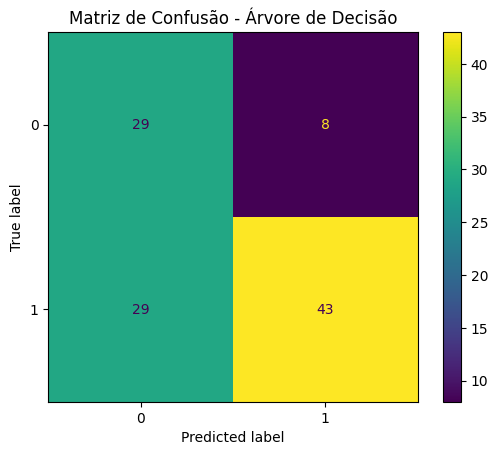

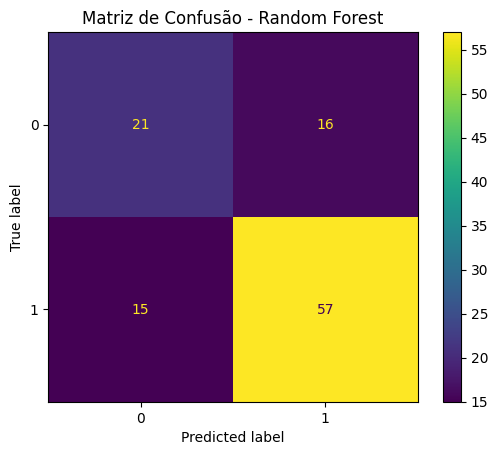

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y, y_pred_arvore)
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

ConfusionMatrixDisplay.from_predictions(y, y_pred_rf)
plt.title("Matriz de Confusão - Random Forest")
plt.show()

## Comparação entre os modelos

O Random Forest apresentou desempenho superior ao Dummy Classifier, especialmente em acurácia e balanced accuracy, indicando que o modelo foi capaz de aprender padrões além da classe majoritária.

Em comparação com a Árvore de Decisão simples, o Random Forest apresentou maior acurácia, recall e F1-score. Entretanto, a Árvore de Decisão obteve balanced accuracy ligeiramente superior, sugerindo melhor equilíbrio entre as classes nesta configuração inicial.

Considerando o tamanho reduzido e a alta quantidade de valores ausentes na base, os resultados devem ser interpretados como preliminares e exploratórios. O objetivo principal desta etapa é avaliar a viabilidade do uso de modelos de Machine Learning como apoio à triagem inicial de compostos com potencial remineralizador.

## Interpretação da matriz de confusão

A matriz de confusão mostrou diferenças importantes entre a Árvore de Decisão e o Random Forest.

A Árvore de Decisão apresentou melhor desempenho na identificação da classe 0, correspondente aos compostos sem evidência de mineralização. No entanto, o modelo apresentou uma quantidade elevada de falsos negativos, classificando como não mineralizadores diversos compostos que pertenciam à classe positiva.

O Random Forest, por outro lado, apresentou maior capacidade de identificação da classe positiva. O modelo classificou corretamente 57 dos 72 compostos mineralizadores, reduzindo a quantidade de falsos negativos em comparação com a Árvore de Decisão. Apesar disso, apresentou maior número de falsos positivos, classificando alguns compostos não mineralizadores como positivos.

Considerando o objetivo do projeto como uma etapa de triagem preliminar, o Random Forest se mostra interessante por reduzir a chance de descartar compostos potencialmente promissores. Entretanto, os resultados devem ser interpretados com cautela devido ao tamanho reduzido da base e à alta quantidade de valores ausentes.